In [1]:
import xarray as xr
import numpy as np
import importlib
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.lines as mlines

from utils.paths import WAVE_DIR, DAC_DIR, GENERATED_TIDES_DIR, HARMONISED_DATA_DIR, WIND_DIR, SLA_DIR
from utils import utils, map_utils
from pathlib import Path
from shapely.geometry import box, Point
from sklearn.decomposition import PCA
from tqdm import tqdm

from cartopy.mpl.geoaxes import GeoAxes
from typing import cast

# Setup


In [2]:
dac_dir = DAC_DIR / "aviso_mog2d"
tide_dir = GENERATED_TIDES_DIR / "fes2022_extrapolated"
swh_tp_dir = WAVE_DIR / "swh_tp"
wave_dir_dir = WAVE_DIR / "mwd_hmax_mdts_mdww_dwps_dwww"
wind_dir = WIND_DIR / "u10_v10"
sla_dir = SLA_DIR / "oras5"

extent = [-0.3, 1.7, 4.75, 6.1]

HARMONISED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def reload_utils():
    importlib.reload(utils)
    importlib.reload(map_utils)


def get_ds(dir_path: Path):
    filepaths = [str(path) for path in (dir_path).glob("*.nc")]

    return xr.open_mfdataset(filepaths)

In [4]:
def assign_to_nearest_grid(values, grid, tol=0.25):
    values = np.array(values)
    grid = np.array(grid)
    assigned = np.full_like(values, np.nan, dtype=float)

    for i, val in enumerate(values):
        diffs = val - grid

        mask = (diffs >= -tol) & (diffs < tol)
        if np.any(mask):
            nearest_idx = np.argmin(np.abs(diffs[mask]))
            assigned[i] = grid[mask][nearest_idx]

    return assigned


def assign_nearest_era5_grid(ds: xr.Dataset):
    swh_tp = get_ds(swh_tp_dir)
    swh_tp = swh_tp.sortby(["latitude", "valid_time"])
    swh_tp = swh_tp.sel(latitude=slice(5, None))

    era5_lats = swh_tp["latitude"].values
    era5_lons = swh_tp["longitude"].values

    input_lats = ds["latitude"].values
    input_lons = ds["longitude"].values

    lat_bin = assign_to_nearest_grid(input_lats, era5_lats)
    lon_bin = assign_to_nearest_grid(input_lons, era5_lons)

    ds = ds.assign_coords(
        latitude=("latitude", lat_bin),
        longitude=("longitude", lon_bin),
        original_lat=("latitude", input_lats),
        original_lon=("longitude", input_lons)
    )

    ds = ds.dropna(dim="latitude", subset=["latitude"])
    ds = ds.dropna(dim="longitude", subset=["longitude"])

    return ds

In [5]:
def compute_coastline_orientation():

    world_coastline = gpd.read_file("data/ne_10m/ne_10m_coastline.shp")
    world_coastline = world_coastline.to_crs(epsg=32630)

    bbox_geom = box(0.7, 4, 1.185, 6.3)
    keta_bbox = gpd.GeoDataFrame(geometry=[bbox_geom],
                                crs="EPSG:4326").to_crs(world_coastline.crs)  # noqa # type: ignore

    keta_coastline = world_coastline.clip(keta_bbox)

    # get coastline length
    keta_coastline_dissolved = keta_coastline.dissolve()
    length_m = keta_coastline_dissolved.geometry.length.iloc[0]
    print(length_m)

    coords = []
    for geom in keta_coastline.geometry:
        if geom.geom_type == "LineString":
            coords.extend(geom.coords)
        elif geom.geom_type == "MultiLineString":
            for part in geom:
                coords.extend(part.coords)

    coords = np.array(coords)
    pca = PCA(n_components=2)
    pca.fit(coords)

    pc = pca.components_[0]
    angle_rad = np.arctan2(pc[1], pc[0])
    mean_tangent_angle = (np.degrees(angle_rad) + 360) % 360
    coastline_orientation = (mean_tangent_angle + 90) % 360

    return coastline_orientation.round(1), {"pc": pc,
                                            "keta_coast": keta_coastline,
                                            "coords": coords,
                                            "coast_length": round(length_m/1000, 1)}


def plot_coastline_orientation(orientation, details):
    pc, keta_coast = details["pc"], details["keta_coast"]
    coords, coast_length = details["coords"], details["coast_length"]

    c1 = "r"
    c2 = "b"

    # Change projection from UTM(zone=30) to PlateCarree
    keta_coast = keta_coast.to_crs(epsg=4326)
    projected_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in coords],
                                     crs="EPSG:32630").to_crs(epsg=4326)
    coords = np.array([[pt.x, pt.y] for pt in projected_gdf.geometry])

    center = coords.mean(axis=0)
    center = center + [0.00, -0.15]

    scale = 0.1  # degrees
    tangent_vector = pc * scale
    normal_vector = np.array([-pc[1], pc[0]]) * scale

    world = gpd.read_file("data/ne_10m/ne_10m_admin_0_countries.shp")
    ghana = world.query("SOV_A3 == 'GHA'")

    fig, ax = plt.subplots(figsize=(5, 5),
                           subplot_kw={"projection": ccrs.PlateCarree()})
    ax = cast(GeoAxes, ax)
    ax.set_extent([0.5, 1.8, 5.5, 6.11])
    ax.set_axis_off()
    map_utils.add_surface_types(ax, ["land", "borders", "coastline"])

    ghana.plot(ax=ax)

    keta_coast = keta_coast.to_crs(epsg=4326)
    keta_coast.plot(ax=ax, color=c2, linewidth=1.2,
                    label="Extracted Coastline")

    quiver_params = {"transform": ccrs.PlateCarree(),
                     "scale_units": "xy",
                     "scale": 0.54,
                     "width": 0.007,
                     "zorder": 6
                     }

    ax.quiver(center[0], center[1], tangent_vector[0], tangent_vector[1],
              color=c2, label="Tangent (PCA direction)",
              **quiver_params)
    ax.quiver(center[0], center[1], normal_vector[0], normal_vector[1],
              color=c1, label="Normal (Onshore direction)",
              **quiver_params)

    text = f"Coastline Orientation: {orientation}°\nCoastline Length: {coast_length} km"
    t = ax.text(center[0], center[1]-0.15,
                text,
                fontsize=10,
                verticalalignment="bottom",
                horizontalalignment="center")

    map_utils.add_halos(t, 1.5)
    # --- LEGEND ---
    tangent_handle = mlines.Line2D([], [], color=c2,
                                   marker=r'$\rightarrow$', linestyle="None",
                                   markersize=12)
    normal_handle = mlines.Line2D([], [], color=c1,
                                  marker=r'$\uparrow$', linestyle="None",
                                  markersize=12)

    # --- handle for coastline (line) ---
    coastline_handle = mlines.Line2D([], [], color=c2,
                                     linewidth=1.5, linestyle="-")

    legend = ax.legend([normal_handle, tangent_handle, coastline_handle],
                       ["Extracted Coastline", "Tangent (PCA direction)",
                        "Normal (Onshore direction)"],
                       edgecolor="none", facecolor="none",
                       loc='upper right',
                       )
    for t in legend.get_texts():
        map_utils.add_halos(t, 1.5)

    plt.tight_layout()
    plt.show()


def compute_wave_directional_features(dir_degrees: xr.DataArray):
    coastline_orientation, _ = compute_coastline_orientation()

    # onshore wave component
    theta_rad = np.radians(coastline_orientation)
    nx = np.cos(theta_rad)
    ny = np.sin(theta_rad)

    dir_rad = np.radians((dir_degrees + 180) % 360)
    wave_u = np.cos(dir_rad)
    wave_v = np.sin(dir_rad)

    onshore_wave = wave_u * nx + wave_v * ny

    relative_angle = np.abs(dir_degrees - coastline_orientation)
    relative_angle = xr.where(relative_angle > 180,
                              360-relative_angle,
                              relative_angle)

    return onshore_wave, relative_angle

73571.47944541069


c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


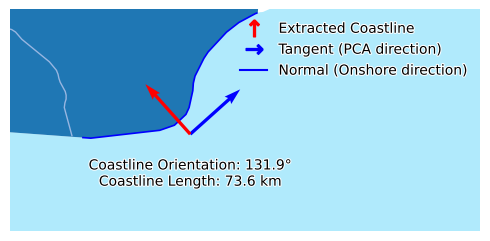

In [6]:
orientation, deets = compute_coastline_orientation()
plot_coastline_orientation(orientation, deets)

Variables


# Preprocessing


## P1: Downsampling FES

1. The data covers a large area, including land and offshore. So it going to be restricted
2. The data has a spatial resolution of 1/16°. It is going to be upsampled to 0.5°. The coordinates are going match those of era5


In [7]:
tide = get_ds(tide_dir)
tide = tide.sortby(["latitude", "longitude"])

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


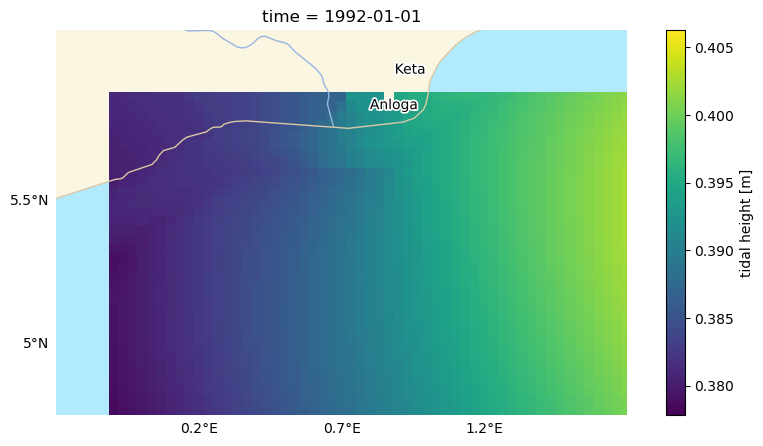

In [8]:
fig, ax, projection = map_utils.make_map(extent)
tide.isel(time=0)["tide_m"].plot(ax=ax, transform=projection)  # noqa #type: ignore

In [9]:
tide = assign_nearest_era5_grid(tide)
tide

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 298056, latitude: 34, longitude: 60)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1992-01-01 ... 2025-12-31T23:00:00
  * latitude      (latitude) float64 272B 5.0 5.0 5.0 5.0 ... 6.0 6.0 6.0 6.0
  * longitude     (longitude) float64 480B 0.2 0.2 0.2 0.2 ... 1.7 1.7 1.7 1.7
    original_lat  (latitude) float64 272B 4.767 4.8 4.833 ... 5.8 5.833 5.867
    original_lon  (longitude) float64 480B -0.03333 0.0 0.03333 ... 1.9 1.933
Data variables:
    tide_m        (time, latitude, longitude) float64 5GB dask.array<chunksize=(2184, 19, 33), meta=np.ndarray>
Attributes: (12/18)
    title:                1992 Hourly Tidal Sea Surface Height Prediction usi...
    summary:              This dataset contains predicted tidal sea surface h...
    source:               Harmonic Analysis using pyTMD with FES2022_extrapol...
    history:              Created on 2025-10-16 using xarry in Python
    references:           https://pytmd.readthedocs.io/en/latest/api_referenc...
    description:           FES2022_extrapolated tidal outputs for Keta region
    ...                   ...
    institution:          Kwame Nkrumah University of Science and Technology
    geospatial_lat_min:   4.633333333333326
    geospatial_lat_max:   5.86666666666666
    geospatial_lon_min:   -0.10000000000002274
    geospatial_lon_max:   2.1
    data_create:          2025-10-16

In [ ]:
output_path_p1 = HARMONISED_DATA_DIR / "tide_stats_on_era5_grid"
output_path_p1.mkdir(parents=True, exist_ok=True)
utils.process_yearly_spatial_stats(tide, output_path_p1, "tide_m")

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


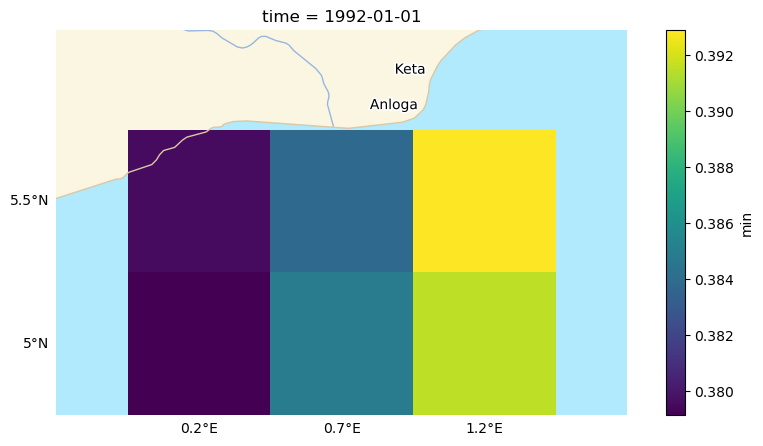

In [11]:
fig, ax, projection = map_utils.make_map(extent)
xr.load_dataset(HARMONISED_DATA_DIR / "tide_stats_on_era5_grid" / "1992.nc").sel(longitude=[0.2, 0.7, 1.2], latitude=[5.0,5.5]).isel(time=0)["min"].plot(ax=ax, transform=projection)  # noqa #type: ignore

## P2: Calculating Wave Run Up


c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


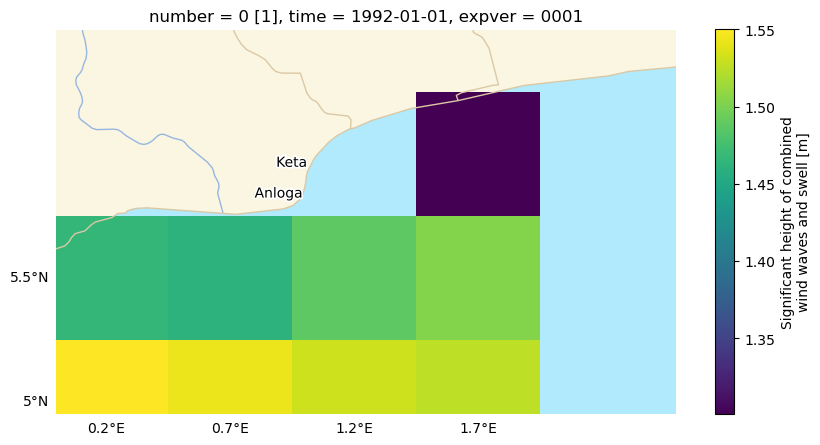

In [13]:
swh_tp = get_ds(swh_tp_dir)
swh_tp = swh_tp.sortby(["latitude", "valid_time"])
swh_tp = swh_tp.rename({"valid_time":"time"})
swh_tp = swh_tp.sel(latitude=slice(5, None))

fig, ax, transform = map_utils.make_map([0.0, 2.5, 4.95, 6.5])
swh_tp.isel(time=0)["swh"].plot(ax=ax, transform=transform)  # noqa # type: ignore

Wave run-up $R$ is calculated using the formula from Brempong's paper:

$$
R=0.043\sqrt{H_s \cdot L_o}
$$

$H_s$: significant wave height in meters\
$L_o$: deep water wavelenght, which can be estimated from peak wave period using the formula:

$$
L_0=\frac{g \cdot T_p^2}{2\pi}
$$

TODO\
The above formula is for beaches with flat slopes. Try the other [formula](https://www.nature.com/articles/s41467-021-24008-9#Sec7) for steeper slopes


In [14]:
Hs = swh_tp["swh"]
Tp = swh_tp["pp1d"]

# calculate deep water wavelength L_o
g = 9.81  # gravitation acceleration
Lo = (g * Tp**2) / (2 * np.pi)  # deep water wavelength [m]

# calculate wave run-up R
R = 0.043 * np.sqrt(Hs * Lo)
swh_tp["run_up"] = R

# calculate rate of change for wave runup
dt = swh_tp["time"].diff("time") / np.timedelta64(1, "h")
dy = swh_tp["run_up"].diff(dim="time")
rate_of_change = dy / dt.broadcast_like(dy)
rate_of_change = rate_of_change.assign_coords(time=swh_tp["time"][1:])

swh_tp["run_up_roc"] = rate_of_change

swh_tp.to_netcdf(f"{HARMONISED_DATA_DIR}/wave_run_up.nc")

## P3: Downsampling DAC

1. The data covers a large area, including land and offshore. So it going to be restricted
2. The data has a spatial resolution of 0.25°. It is going to be upsampled to 0.5°. The coordinates are going match those of era5
3. The data has a temporal resolution of 6 hours. It's going to to be downsampled to hourly


In [15]:
dac = get_ds(dac_dir)
dac = dac.sortby(["latitude", "longitude"])

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


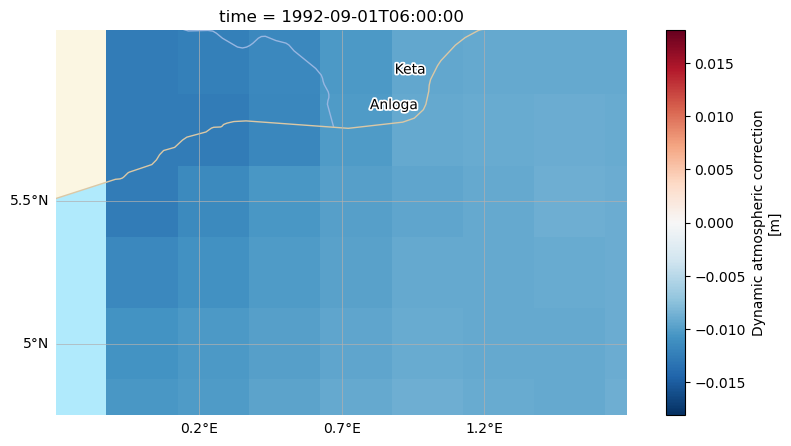

In [16]:
fig, ax, projection = map_utils.make_map(extent,gridline_width=0.5)
dac.isel(time=0)["dac"].plot(ax=ax, transform=projection)  # noqa # type: ignore

Temporal downsampling from 6 hourly to hourly


In [17]:
dac = dac.resample(time="1h").interpolate()
dac_hourly = dac.sel(time=slice(dac["time"].min(), dac["time"].max()))


dac

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 289963, latitude: 33, longitude: 15)
Coordinates:
  * latitude   (latitude) float64 264B 0.0 0.25 0.5 0.75 ... 7.25 7.5 7.75 8.0
  * longitude  (longitude) float64 120B 0.0 0.25 0.5 0.75 ... 2.75 3.0 3.25 3.5
  * time       (time) datetime64[ns] 2MB 1992-09-01T06:00:00 ... 2025-09-30
Data variables:
    dac        (time, latitude, longitude) float64 1GB dask.array<chunksize=(289963, 5, 3), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        MOG2D-G HR barotropic model output (high frequencies) combi...
    institution:  CNES/CNRS-LEGOS/CLS
    source:       MOG2D-G(Pressure+Wind)+Inverted Barometer, system version 2...
    history:      no
    references:   http://www.aviso.oceanobs.com
    comment:      Low Frequencies/High Frequencies:20 day cutoff

In [18]:
dac = assign_nearest_era5_grid(dac)
dac

<xarray.Dataset> Size: 114MB
Dimensions:       (time: 289963, latitude: 6, longitude: 8)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1992-09-01T06:00:00 ... 2025-09-30
  * latitude      (latitude) float64 48B 5.0 5.0 5.5 5.5 6.0 6.0
  * longitude     (longitude) float64 64B 0.2 0.2 0.7 0.7 1.2 1.2 1.7 1.7
    original_lat  (latitude) float64 48B 4.75 5.0 5.25 5.5 5.75 6.0
    original_lon  (longitude) float64 64B 0.0 0.25 0.5 0.75 1.0 1.25 1.5 1.75
Data variables:
    dac           (time, latitude, longitude) float64 111MB dask.array<chunksize=(289963, 4, 2), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        MOG2D-G HR barotropic model output (high frequencies) combi...
    institution:  CNES/CNRS-LEGOS/CLS
    source:       MOG2D-G(Pressure+Wind)+Inverted Barometer, system version 2...
    history:      no
    references:   http://www.aviso.oceanobs.com
    comment:      Low Frequencies/High Frequencies:20 day cutoff

In [ ]:
output_path_p3 = HARMONISED_DATA_DIR / "dac_stats_on_era5_grid"
output_path_p3.mkdir(parents=True, exist_ok=True)


utils.process_yearly_spatial_stats(dac, output_path_p3, "dac")

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


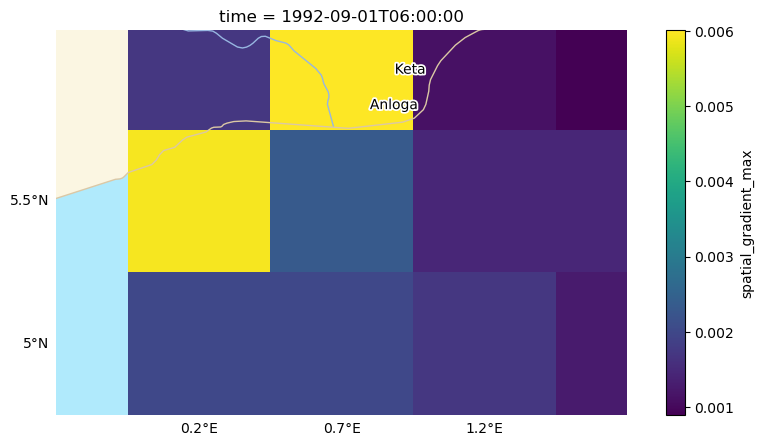

In [19]:
fig, ax, projection = map_utils.make_map(extent)
xr.load_dataset(HARMONISED_DATA_DIR / "dac_stats_on_era5_grid" / "1992.nc").isel(time=0)["spatial_gradient_max"].plot(ax=ax, transform=projection)  # noqa #type: ignore

## P4: Calculating Wind Speed and Wind Direction

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


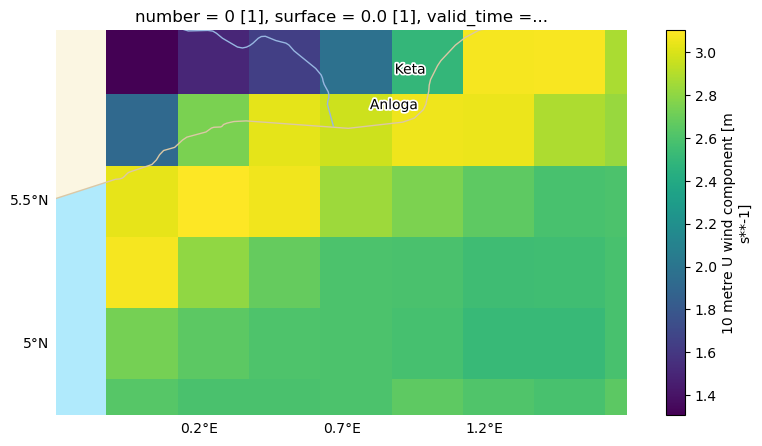

In [20]:
wind = get_ds(wind_dir)
wind = wind.sel(latitude=slice(4.75, None), longitude=slice(0, 1.8))


fig, ax, projection = map_utils.make_map(extent,)
wind.isel(valid_time=0)["u10"].plot(ax=ax, transform=projection)  # noqa # type: ignore
plt.show()

In [21]:
wind["speed"] = np.sqrt(wind["u10"]**2 + wind["v10"]**2)

wind["direction"] = np.arctan2(wind["v10"], wind["u10"])
wind["direction"] = (np.degrees(wind["direction"]) + 180) % 360

In [22]:
coastline_orientation, _ = compute_coastline_orientation()

wind["relative_angle"] = np.abs(wind["direction"] - coastline_orientation)
wind["relative_angle"] = xr.where(
    wind["relative_angle"] > 180,
    360 - wind["relative_angle"],
    wind["relative_angle"]
)

theta_rad = np.radians(coastline_orientation)
nx = np.cos(theta_rad)
ny = np.sin(theta_rad)

wind_dir_rad = np.radians((wind["direction"] + 180) % 360)
wind_u_dir = np.cos(wind_dir_rad)
wind_v_dir = np.sin(wind_dir_rad)

wind["onshore"] = wind_u_dir * nx + wind_v_dir * ny

73571.47944541069


In [23]:
wind = wind.rename({"valid_time": "time"})
wind.to_netcdf(HARMONISED_DATA_DIR / "wind.nc")

## P5: Mean Wave Direction, Maximun Individual Wave Height, Mean Direction of Total Swell, Mean Direction of Wind Waves, Wave Spectral Directional Width for Swell, Wave Spectral Directional Width for Wind Waves

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


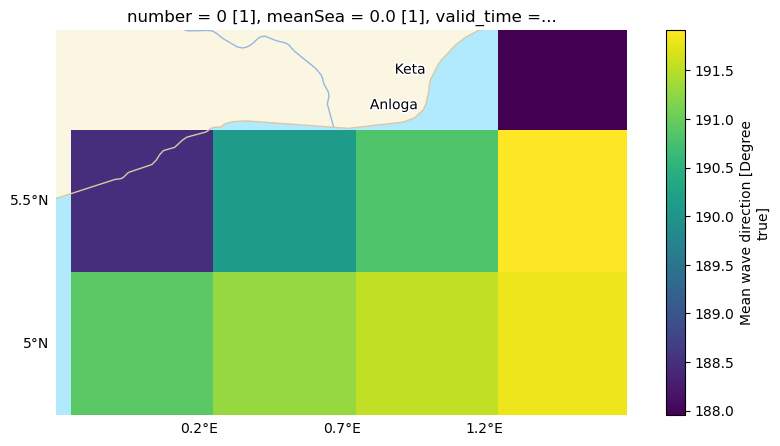

In [24]:
wave_dir = get_ds(wave_dir_dir)
wave_dir = wave_dir.sel(latitude=slice(4.75, None), longitude=slice(0, 1.8))  # noqa

fig, ax, projection = map_utils.make_map(extent,)
wave_dir.isel(valid_time=0)["mwd"].plot(ax=ax, transform=projection)  # noqa # type: ignore
plt.show()

In [25]:
wave_dir["mwd_onshore"], wave_dir["mwd_relative_angle"] = compute_wave_directional_features(
    wave_dir["mwd"])
wave_dir["mdts_onshore"], wave_dir["mdts_relative_angle"] = compute_wave_directional_features(
    wave_dir["mdts"])
wave_dir["mdww_onshore"], wave_dir["mdww_relative_angle"] = compute_wave_directional_features(
    wave_dir["mdww"])


73571.47944541069
73571.47944541069
73571.47944541069


In [26]:
# wave_dir["dwps"] = np.rad2deg(wave_dir["dwps"])
# wave_dir["dwww"] = np.rad2deg(wave_dir["dwww"])

wave_dir["spread_diff"] = wave_dir["dwps"] - wave_dir["dwww"]


In [27]:
wave_dir

<xarray.Dataset> Size: 271MB
Dimensions:              (valid_time: 294050, latitude: 3, longitude: 4)
Coordinates:
    number               int64 8B 0
    meanSea              float64 8B 0.0
  * valid_time           (valid_time) datetime64[ns] 2MB 1992-01-01 ... 2025-...
  * latitude             (latitude) float64 24B 5.0 5.5 6.0
  * longitude            (longitude) float64 32B 0.0 0.5 1.0 1.5
Data variables: (12/13)
    mwd                  (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    hmax                 (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    mdts                 (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    mdww                 (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    dwps                 (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    dwww                 (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    ...                   ...
    mwd_relative_angle   (valid_time, latitude, longitude) float64 28MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    mdts_onshore         (valid_time, latitude, longitude) float64 28MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    mdts_relative_angle  (valid_time, latitude, longitude) float64 28MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    mdww_onshore         (valid_time, latitude, longitude) float64 28MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    mdww_relative_angle  (valid_time, latitude, longitude) float64 28MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
    spread_diff          (valid_time, latitude, longitude) float32 14MB dask.array<chunksize=(17544, 3, 4), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-22T04:59 GRIB to CDM+CF via cfgrib-0.9.1...

In [28]:
wave_dir = wave_dir.rename({"valid_time": "time"})
wave_dir.to_netcdf(HARMONISED_DATA_DIR / "wave_direction.nc")

## P6: Sea Surface Height

In [29]:
from scipy.interpolate import griddata
import pandas as pd

In [30]:
MIN_LAT, MAX_LAT = 4.5, 6.5
MIN_LON, MAX_LON = -0.3, 2.3
TARGET_RES = 0.5

ssh_var = "sossheig"
lon_var = "nav_lon"
lat_var = "nav_lat"

ssh = get_ds(sla_dir)

ssh_da = ssh[ssh_var]

lons_2d = ssh[lon_var]
lats_2d = ssh[lat_var]

time_coords = ssh["time_counter"].values
time_coords = time_coords.astype("datetime64[M]").astype("datetime64[ns]")

print(f"Loaded data with shape: {ssh_da.shape}")

# --- COMPUTE SLA ---
reference_period = ssh_da.sel(time_counter=slice("1992-01-01", "2020-12-31"))
climatology = reference_period.groupby("time_counter.month").mean("time_counter")

sla = ssh_da.groupby("time_counter.month") - climatology
sla.name = "sla"

# --- REGRD DATA ---


mask = (
    (lats_2d >= MIN_LAT) & (lats_2d <= MAX_LAT) &
    (lons_2d >= MIN_LON) & (lons_2d <= MAX_LON)
).compute()

lons_subset = lons_2d.where(mask)
lats_subset = lats_2d.where(mask)

source_lons_flat = lons_subset.stack(points=("y", "x")).compute()
source_lats_flat = lats_subset.stack(points=("y", "x")).compute()

valid_grid_idxs = ~np.isnan(source_lons_flat)

source_lons_1d = source_lons_flat[valid_grid_idxs]
source_lats_1d = source_lats_flat[valid_grid_idxs]

source_points = np.vstack((source_lons_1d, source_lats_1d)).T

# print(f"Found {len(source_points)} valid source grid points in subset.")

new_lon = np.array([0.2, 0.7, 1.2, 1.7])
new_lat = np.array([5.0, 5.5])

target_lon_mesh, target_lat_mesh = np.meshgrid(new_lon, new_lat)

print("Regridding all time slices...")
regridded_slices = []

for i in tqdm(range(len(time_coords)), desc="Regridding slices"):
    sla_slice = sla.isel(time_counter=i)
    sla_slice = sla_slice.load()

    sla_slice_subset = sla_slice.where(mask)

    source_values_flat = sla_slice_subset.stack(points=("y", "x"))

    source_values_on_grid = source_values_flat[valid_grid_idxs]

    valid_data_mask = ~np.isnan(source_values_on_grid)

    final_source_points = source_points[valid_data_mask]
    final_source_values = source_values_on_grid[valid_data_mask]

    regridded_values = griddata(
        final_source_points,
        final_source_values,
        (target_lon_mesh, target_lat_mesh),
        method='linear'
    )

    regridded_slices.append(regridded_values)

regridded_3d_array = np.stack(regridded_slices, axis=0)

sla_regridded = xr.DataArray(
    regridded_3d_array,
    coords={'time': time_coords, 'latitude': new_lat, 'longitude': new_lon},
    dims=['time', 'latitude', 'longitude'],
    name='sla'
)

Loaded data with shape: (405, 1021, 1442)
Regridding all time slices...


Regridding slices: 100%|██████████| 405/405 [12:50<00:00,  1.90s/it]


In [31]:
sla_regridded.attrs = ssh_da.attrs
sla_regridded["time"].attrs = ssh["time_counter"].attrs

sla_regridded.latitude.attrs = {
    'long_name': 'Latitude',
    'standard_name': 'latitude',
    'units': 'degrees_north'
}

sla_regridded.longitude.attrs = {
    'long_name': 'Longitude',
    'standard_name': 'longitude',
    'units': 'degrees_east'
}

import datetime
history_log = (
    f"{datetime.datetime.now(datetime.timezone.utc).isoformat()}: "
    f"Regridded to {TARGET_RES}-deg regular grid from ORAS5 native grid "
    "using linear interpolation."
)
sla_regridded.attrs['history'] = history_log


c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


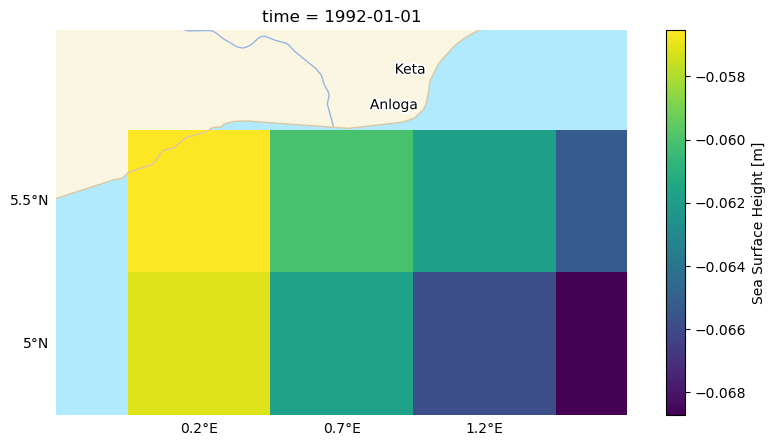

In [32]:
fig, ax, projection = map_utils.make_map(extent,)
sla_regridded.isel(time=0).plot(ax=ax, transform=projection)  # noqa # type: ignore


In [33]:
# --- CALCULATE SLA ---
sla_regridded.attrs = {
    'long_name': 'Sea Level Anomaly',
    'units': 'm',
    'description': 'Sea Surface Height (ssh) with the 1993-2020 mean seasonal cycle removed.'
}

In [34]:
sea = xr.Dataset({
    # 'ssh': ssh_regridded,
    'sla': sla_regridded
})

start = sea["time"].values[0]
end = sea['time'].values[-1] + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23)
new_time_idx = pd.date_range(start, end, freq="1h")

sea = sea.interp(time=new_time_idx)

sea.attrs = {
    'title': 'ORAS5 Regridded Sea Level Data for ERA5 Grid',
    'source_data': 'ORAS5 sossheig (zos)',
    'reference_period_for_sla': '1993-01-01 to 2020-12-31',
    'history': 'Created on 2025-10-23. Regridded from native tripolar grid.'
}

sea.to_netcdf(HARMONISED_DATA_DIR / "sea.nc")

c:\Users\steve\miniconda3\envs\data-processing\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


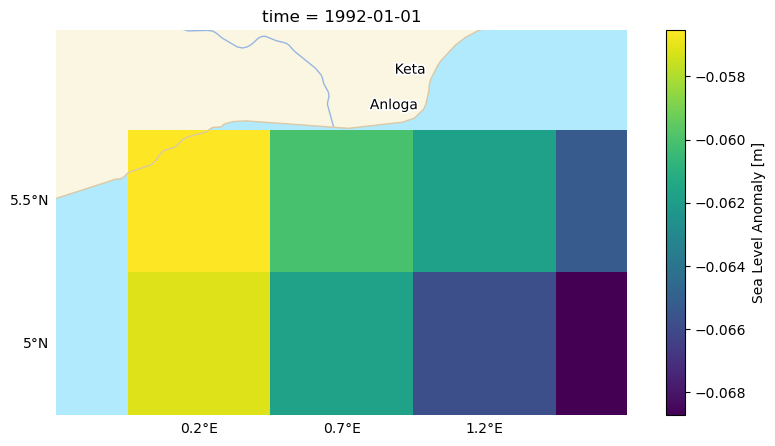

In [36]:
fig, ax, projection = map_utils.make_map(extent,)
xr.open_dataset(HARMONISED_DATA_DIR / "sea.nc").isel(time=0)["sla"].plot(ax=ax, transform=projection)